In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix,precision_score, recall_score,f1_score,roc_curve, roc_auc_score, classification_report

In [10]:
data = pd.read_excel('Merged_HOA_ARC_ECU_WCP.xlsx')
data.head()

,source_file,event_id,date,year,country,region,Location,latitude,longitude,loc_accuracy,...,FoodInsecurity,Marginalization,StratLoc,MaritimeCrime,violence_score,ViolenceScore_Explanation,Explanation,Summary,Disputed,ForcedLabor
0,ArcticAlaska_Conflict_Final,alaska8452,2023-08-12,2023,USA,Arctic,Aleutian Islands subarea of the Bering Sea and...,52.194868,-171.238410,NaN,...,0,0,0,0,NaN,NaN,The National Marine Fisheries Service (NMFS) h...,The National Marine Fisheries Service (NMFS) h...,NaN,NaN
1,ArcticAlaska_Conflict_Final,alaska179,2023-10-26,2023,USA,Arctic,Bering Sea and Aleutian Islands,54.742445,-168.151825,NaN,...,0,0,0,0,NaN,NaN,The Center for Biological Diversity has announ...,The Center for Biological Diversity has announ...,NaN,NaN
2,ArcticAlaska_Conflict_Final,alaska7367,2023-09-28,2023,USA,Arctic,Central Aleutian district of the Bering Sea an...,52.112761,-179.377900,NaN,...,0,0,0,0,NaN,NaN,The National Marine Fisheries Service (NMFS) h...,The National Marine Fisheries Service (NMFS) h...,NaN,NaN
3,ArcticAlaska_Conflict_Final,"arctic32266, alaska9843",2022-10-18,2022,USA,Arctic,"Bering Sea, Alaska",56.671516,-177.845779,NaN,...,0,0,0,0,NaN,NaN,The article reports on the government's decisi...,The Alaskan Department of Fish and Game have c...,NaN,NaN
4,ArcticAlaska_Conflict_Final,arctic38061,2022-06-08,2022,USA,Arctic,"Kenai River, Alaska",60.545250,-151.251658,NaN,...,0,0,0,0,NaN,NaN,The Alaska Department of Fish and Game Divisio...,The Alaska Department of Fish and Game Divisio...,NaN,NaN


In [11]:
print(data.shape)
data_dna = data[data.columns[12:28]].dropna()
print(data_dna.shape)
x = data_dna.copy().drop('violence_score', axis=1)
print(x.shape)

y = data_dna['violence_score'].copy()
print(y.shape)

(1059, 33)
(684, 16)
(684, 15)
(684,)


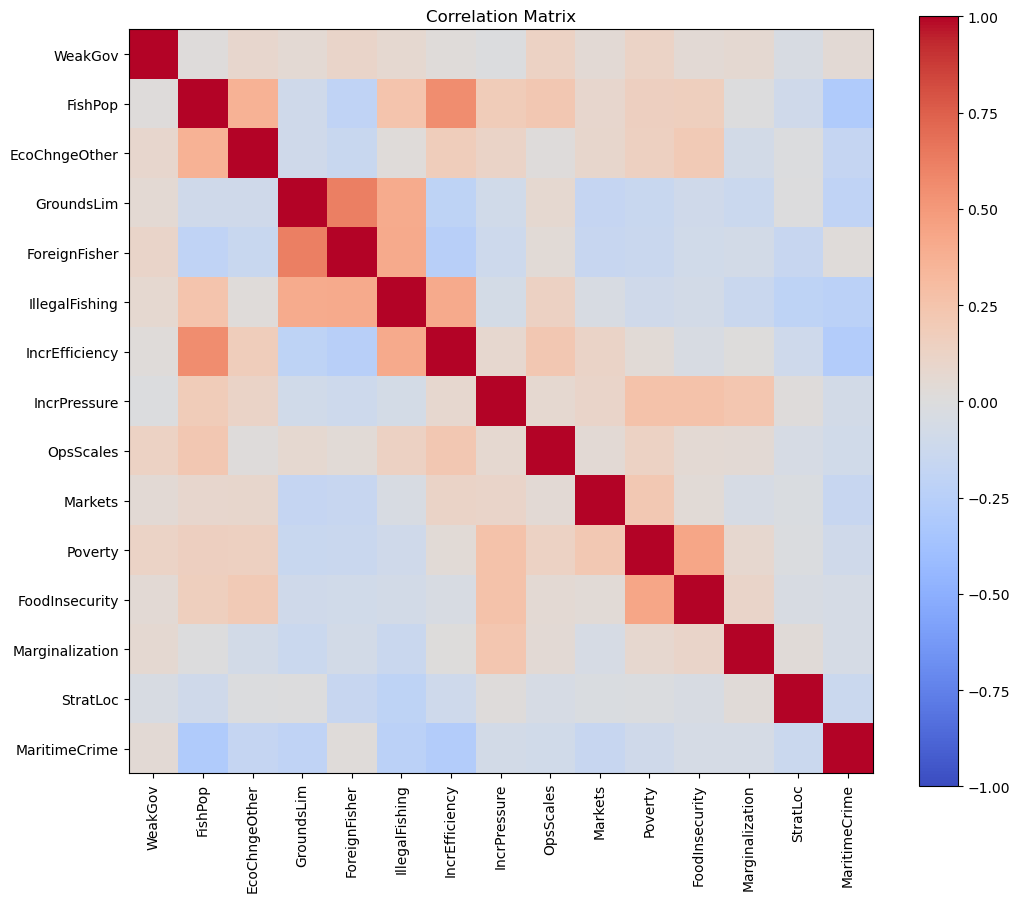

In [42]:
# checking for correlations
corr_matrix = x.corr()
plt.figure(figsize=(12, 10))
plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar()
plt.title('Correlation Matrix')
plt.xticks(range(len(x.columns)), x.columns, rotation=90)
plt.yticks(range(len(x.columns)), x.columns)
plt.show()

In [12]:
xTrain, xTest, yTrain, yTest = train_test_split(x, y, test_size=0.2, random_state=117)

In [19]:
logreg = LogisticRegression(solver='lbfgs')
logreg.fit(xTrain, yTrain)

yPred = logreg.predict(xTest)
print("Accuracy:", accuracy_score(yTest, yPred))
print("classification report:\n", classification_report(yTest, yPred))


Accuracy: 0.708029197080292
classification report:
               precision    recall  f1-score   support

         1.0       0.80      0.71      0.75        49
         2.0       0.70      0.84      0.76        68
         3.0       0.45      0.25      0.32        20

    accuracy                           0.71       137
   macro avg       0.65      0.60      0.61       137
weighted avg       0.70      0.71      0.69       137



In [36]:
pipeline = Pipeline([
    ('logregcv',LogisticRegressionCV(Cs=[0.1, .5, 1], 
                                    l1_ratios=[.1,.5,1], #first run suggested l1_ratio=.1, so narrowing down to ridge regression, which is l1_ratio=0
                                    cv=5, solver='saga',
                                    max_iter=1000, 
                                    class_weight='balanced', 
                                    random_state=117))
])

pipeline.fit(xTrain, yTrain)

yPredCV = pipeline.predict(xTest)
print("Accuracy:", accuracy_score(yTest, yPredCV))
print("classification report:\n", classification_report(yTest, yPredCV))

x:\anaconda\envs\WWF\Lib\site-packages\sklearn\linear_model\_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details.
  warnings.warn(


Accuracy: 0.6423357664233577
classification report:
               precision    recall  f1-score   support

         1.0       0.77      0.73      0.75        49
         2.0       0.75      0.66      0.70        68
         3.0       0.23      0.35      0.28        20

    accuracy                           0.64       137
   macro avg       0.58      0.58      0.58       137
weighted avg       0.68      0.64      0.66       137



In [37]:
fitted_logregcv = pipeline.named_steps['logregcv']
print("Best C:", fitted_logregcv.C_)
print("Best l1_ratio:", fitted_logregcv.l1_ratio_)

Best C: [1. 1. 1.]
Best l1_ratio: [0.1 0.1 0.1]
